# 🌿 Plant Disease Detection — Built from Scratch
### EfficientNetV2S · L4 GPU · 70,000+ Images · 38 Classes
---
| الإعداد | القيمة |
|---|---|
| Base Model | EfficientNetV2S (ImageNet) |
| Image Size | 224 × 224 |
| Batch Size | 128 |
| Mixed Precision | float16 |
| Strategy | 2-Phase Training |


## ✅ الخطوة 1 — التحقق من الـ GPU

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os, json, time, warnings
warnings.filterwarnings('ignore')

gpus = tf.config.list_physical_devices('GPU')
print(f'✅ GPUs: {gpus}')
print(f'✅ TF version: {tf.__version__}')
!nvidia-smi --query-gpu=name,memory.total,memory.free --format=csv,noheader

✅ GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ TF version: 2.20.0
NVIDIA A100-SXM4-40GB, 40960 MiB, 40437 MiB


## ☁️ الخطوة 2 — ربط Google Drive

In [2]:
!pip install opendatasets

## ⚡ الخطوة 3 — نقل البيانات للـ Local Storage (أهم خطوة)

In [3]:
# ============================================================
# 📦 تحميل الداتا من Kaggle مباشرة
# ============================================================
import opendatasets as od
import os
import time

DATASET_URL = "https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset"

LOCAL_PATH = "/content/new-plant-diseases-dataset"

# تحميل مرة واحدة فقط
if not os.path.exists(LOCAL_PATH):
    print("📥 جاري تحميل الداتا من Kaggle...")
    t0 = time.time()
    od.download(DATASET_URL)
    print(f"✅ تم التحميل في {(time.time()-t0)/60:.1f} دقيقة")
else:
    print("✅ الداتا موجودة بالفعل")

# ============================================================
# 📁 تحديد المسارات (مهم جدًا تكون صح)
# ============================================================
BASE_DIR = os.path.join(
    LOCAL_PATH,
    "new plant diseases dataset(augmented)",
    "New Plant Diseases Dataset(Augmented)"
)

TRAIN_DIR = os.path.join(BASE_DIR, "train")
VAL_DIR   = os.path.join(BASE_DIR, "valid")

print(f"\n📁 Train path: {TRAIN_DIR}")
print(f"📁 Val path:   {VAL_DIR}")

# ============================================================
# 🌿 معلومات الداتا
# ============================================================
classes = sorted(os.listdir(TRAIN_DIR))
NUM_CLASSES = len(classes)

print(f"\n🌿 عدد الكلاسات: {NUM_CLASSES}")

# عد الصور
total_train = sum(len(files) for _, _, files in os.walk(TRAIN_DIR))
total_val   = sum(len(files) for _, _, files in os.walk(VAL_DIR))

print(f"📸 صور التدريب: {total_train:,}")
print(f"📸 صور الـ Val: {total_val:,}")

📥 جاري تحميل الداتا من Kaggle...
Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: anas0moamen
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/vipoooool/new-plant-diseases-dataset


100%|██████████| 2.70G/2.70G [00:11<00:00, 260MB/s]



✅ تم التحميل في 1.3 دقيقة

📁 Train path: /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/train
📁 Val path:   /content/new-plant-diseases-dataset/new plant diseases dataset(augmented)/New Plant Diseases Dataset(Augmented)/valid

🌿 عدد الكلاسات: 38
📸 صور التدريب: 70,295
📸 صور الـ Val: 17,572


## ⚙️ الخطوة 4 — الإعدادات (غيّر من هنا فقط)

In [4]:
# ================================================================
#  إعدادات مُحسَّنة لـ Colab L4 GPU (24GB VRAM)
# ================================================================
IMG_SIZE = (224, 224)
BATCH_SIZE = 64   # 🔥 was 128
EPOCHS_PHASE1 = 15
EPOCHS_PHASE2 = 10
LR_PHASE1 = 3e-4  # 🔥 was 1e-3
LR_PHASE2 = 1e-5
DENSE_UNITS = 512  # 🔥 was 256
UNFREEZE_LAYERS = 50
AUTOTUNE = tf.data.AUTOTUNE
SEED = 42

print('✅ الإعدادات جاهزة:')
print(f'   IMG_SIZE      = {IMG_SIZE}')
print(f'   BATCH_SIZE    = {BATCH_SIZE}')
print(f'   NUM_CLASSES   = {NUM_CLASSES}')
print(f'   EPOCHS        = {EPOCHS_PHASE1} + {EPOCHS_PHASE2}')

✅ الإعدادات جاهزة:
   IMG_SIZE      = (224, 224)
   BATCH_SIZE    = 64
   NUM_CLASSES   = 38
   EPOCHS        = 15 + 10


## 🔧 الخطوة 5 — تفعيل Mixed Precision

In [5]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print(f'✅ Policy: {mixed_precision.global_policy().name}')
print('   → بيسرّع الحسابات على L4 تقريباً 1.5-2x')

✅ Policy: mixed_float16
   → بيسرّع الحسابات على L4 تقريباً 1.5-2x


## 🗄️ الخطوة 6 — تحميل البيانات مع Pipeline محسّنة

In [7]:
# ── تحميل الـ datasets ──────────────────────────────────────────
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
    label_mode='int'
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    label_mode='int'
)

CLASS_NAMES = train_ds_raw.class_names
print(f'✅ كلاسات محمّلة: {len(CLASS_NAMES)}')

# Import preprocess_input for EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

# ── Preprocessing ────────────────────────────────────────────────
def preprocess(image, label):
    image = preprocess_input(image)
    return image, label

train_ds = (
    train_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .shuffle(5000)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


# ── Pipeline مُحسَّنة لـ L4 ──────────────────────────────────────
#  prefetch  → GPU تشتغل أثناء تحميل الـ batch الجاي
#  shuffle   → buffer_size كبير لتنويع أفضل
#  cache     → الـ epoch التاني أسرع بكتير

train_ds = (
    train_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .shuffle(buffer_size=5000, seed=SEED)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds_raw
    .map(preprocess, num_parallel_calls=AUTOTUNE)
    .cache()
    .prefetch(AUTOTUNE)
)

print('✅ Pipeline جاهزة')
print(f'   train: {train_ds_raw.cardinality().numpy()} batches')
print(f'   val  : {val_ds_raw.cardinality().numpy()} batches')


Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
✅ كلاسات محمّلة: 38
✅ Pipeline جاهزة
   train: 1099 batches
   val  : 275 batches


## 👀 الخطوة 7 — عرض عينة من البيانات

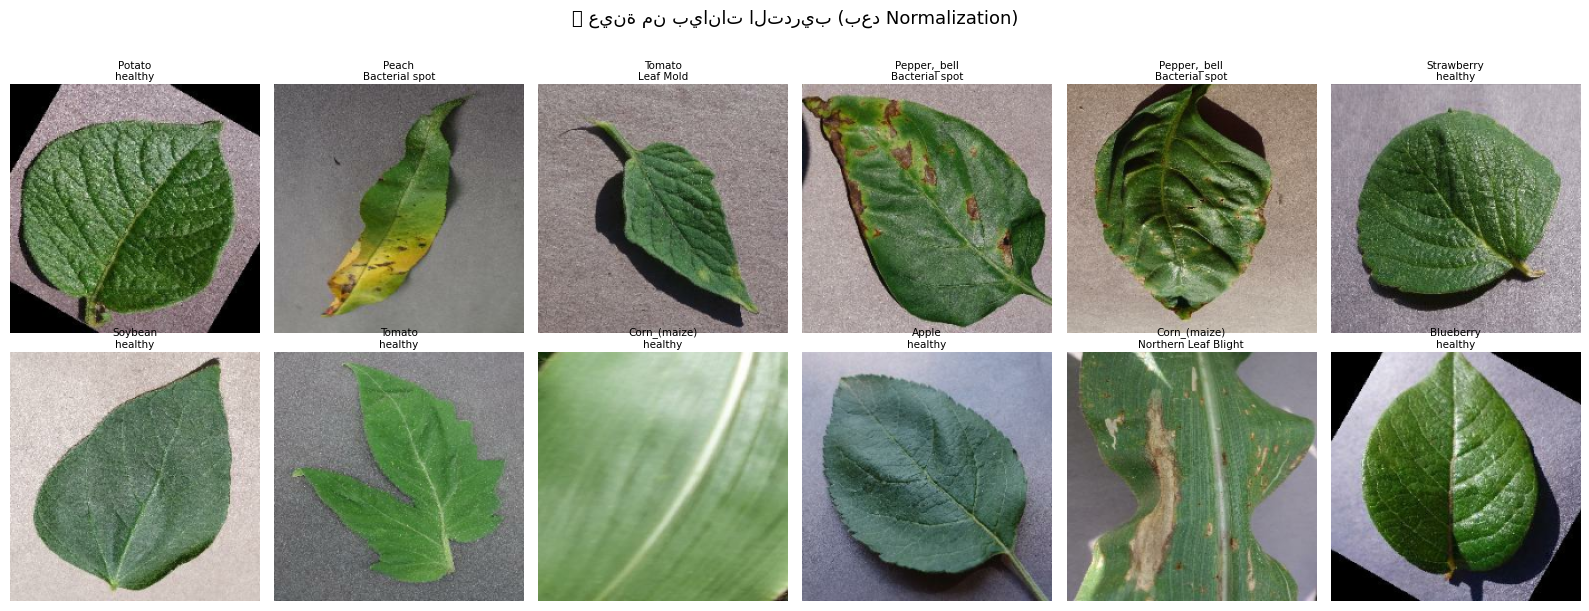

In [8]:
plt.figure(figsize=(16, 6))
for images, labels in train_ds.take(1):
    for i in range(12):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy())
        cls = CLASS_NAMES[labels[i].numpy()]
        plant, disease = (cls.split('___') + [''])[:2]
        plt.title(f'{plant}\n{disease.replace("_"," ")}', fontsize=7.5, pad=3)
        plt.axis('off')
plt.suptitle('🌿 عينة من بيانات التدريب (بعد Normalization)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 📊 الخطوة 8 — توزيع الكلاسات

أقل كلاس:  1,642 صورة
أكتر كلاس: 2,022 صورة
المتوسط:   1850 صورة


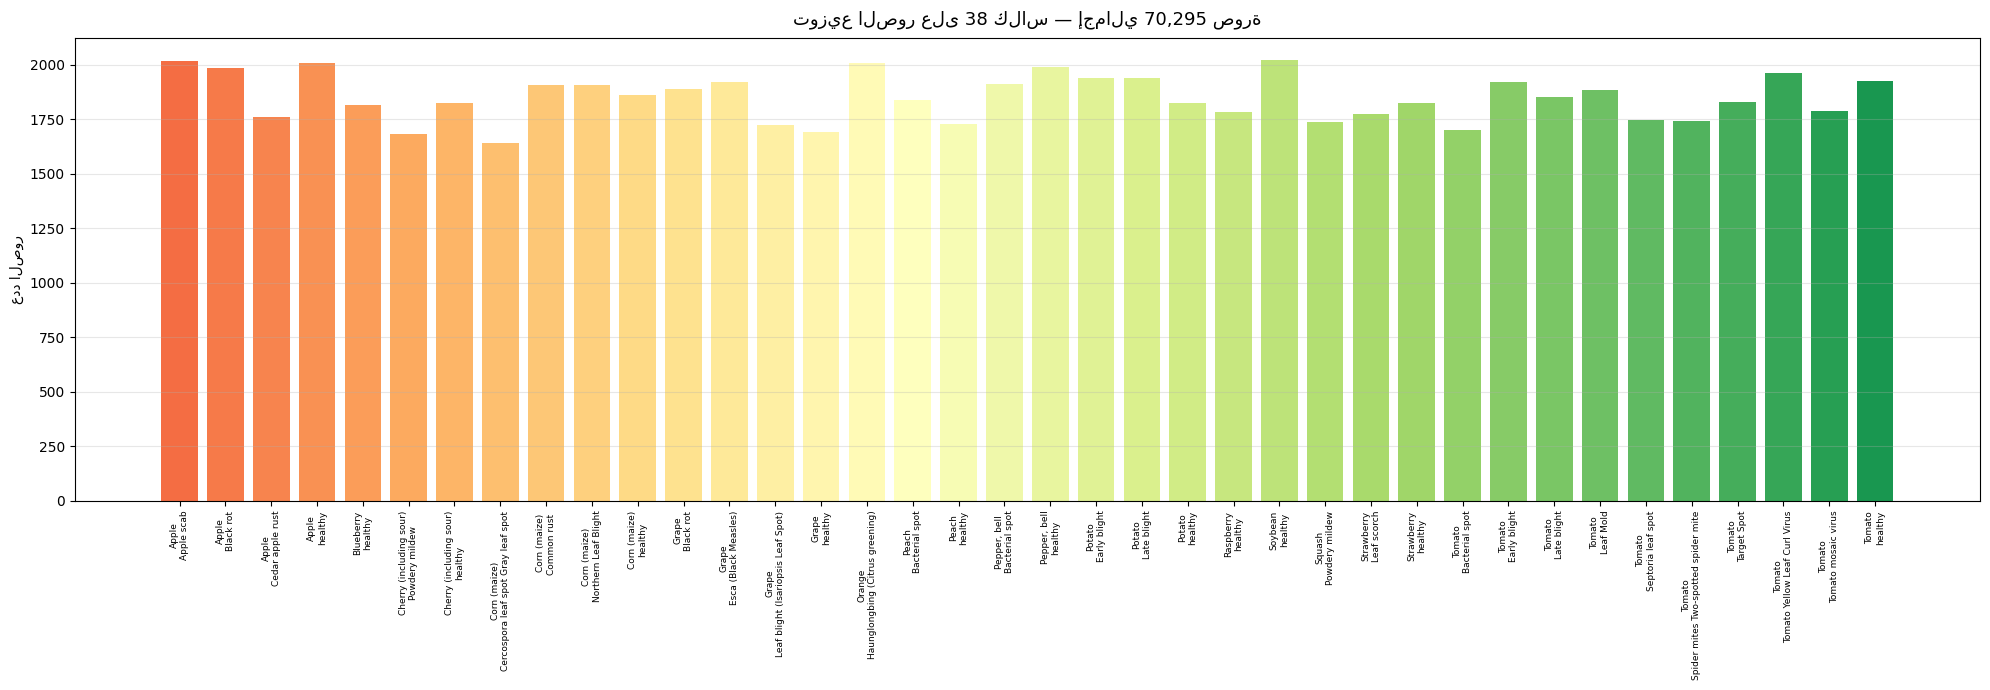

In [8]:
# عد الصور لكل كلاس في التدريب
class_counts = {}
for cls in CLASS_NAMES:
    path = os.path.join(TRAIN_DIR, cls)
    class_counts[cls] = len(os.listdir(path))

counts = list(class_counts.values())
names  = [k.replace('___', '\n').replace('_', ' ') for k in class_counts.keys()]

fig, ax = plt.subplots(figsize=(20, 7))
bars = ax.bar(range(len(names)), counts,
              color=plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(names))))
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=6.5)
ax.set_ylabel('عدد الصور')
ax.set_title(f'توزيع الصور على {NUM_CLASSES} كلاس — إجمالي {sum(counts):,} صورة',
             fontsize=13, pad=10)
ax.grid(axis='y', alpha=0.3)
print(f'أقل كلاس:  {min(counts):,} صورة')
print(f'أكتر كلاس: {max(counts):,} صورة')
print(f'المتوسط:   {np.mean(counts):.0f} صورة')
plt.tight_layout()
plt.show()

## 🏗️ الخطوة 9 — بناء الموديل

In [9]:
from tensorflow.keras import layers, models

# ── Data Augmentation (بيشتغل على الـ GPU مباشرة) ───────────────
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])


# ── Base Model (EfficientNetV2S pretrained على ImageNet) ─────────
base_model = tf.keras.applications.EfficientNetV2S(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# 🔥 Partial training from start
base_model.trainable = True
for layer in base_model.layers[:-UNFREEZE_LAYERS]:
    layer.trainable = False

inputs = layers.Input(shape=(224,224,3))
x = data_augmentation(inputs)
x = base_model(x, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(DENSE_UNITS, activation='relu')(x)
x = layers.Dropout(0.4)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax', dtype='float32')(x)

model = models.Model(inputs, outputs)

# ملخص الـ head فقط
print('\n📋 طبقات الـ Head:')
for layer in model.layers[-6:]:
    print(f'   {layer.name:30s} {str(layer.output.shape):25s} trainable={layer.trainable}')

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

📋 طبقات الـ Head:
   efficientnetv2-s               (None, 7, 7, 1280)        trainable=True
   global_average_pooling2d       (None, 1280)              trainable=True
   batch_normalization            (None, 1280)              trainable=True
   dense                          (None, 512)               trainable=True
   dropout                        (None, 512)               trainable=True
   dense_1                        (None, 38)                trainable=True


## 🚀 الخطوة 10 — Phase 1: تدريب الـ Head (Base مجمّد)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_PHASE1),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🚀 Training Phase 1...")
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE1
)

🚀 Training Phase 1...
Epoch 1/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 205s 106ms/step - accuracy: 0.9069 - loss: 0.3137 - val_accuracy: 0.9793 - val_loss: 0.0630
Epoch 2/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 87s 80ms/step - accuracy: 0.9696 - loss: 0.0894 - val_accuracy: 0.9887 - val_loss: 0.0343
Epoch 3/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 87s 80ms/step - accuracy: 0.9775 - loss: 0.0671 - val_accuracy: 0.9886 - val_loss: 0.0341
Epoch 4/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 87s 79ms/step - accuracy: 0.9809 - loss: 0.0583 - val_accuracy: 0.9914 - val_loss: 0.0261
Epoch 5/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - accuracy: 0.9838 - loss: 0.0507 - val_accuracy: 0.9909 - val_loss: 0.0267
Epoch 6/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 86s 79ms/step - accuracy: 0.9852 - loss: 0.0456 - val_accuracy: 0.9886 - val_loss: 0.0493
Epoch 7/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/step - accuracy: 0.9875 - loss: 0.0381 - val_accuracy: 0.9929 - val_loss: 0.0215
Epoch 8/15
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 86s 78ms/s

## 🔓 الخطوة 11 — Phase 2: Fine-Tuning (فتح آخر الطبقات)

In [11]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_PHASE2),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("🔓 Fine-tuning...")
history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_PHASE2
)


🔓 Fine-tuning...
Epoch 1/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 126s 86ms/step - accuracy: 0.9945 - loss: 0.0176 - val_accuracy: 0.9971 - val_loss: 0.0096
Epoch 2/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 88s 80ms/step - accuracy: 0.9960 - loss: 0.0132 - val_accuracy: 0.9972 - val_loss: 0.0089
Epoch 3/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 88s 81ms/step - accuracy: 0.9964 - loss: 0.0111 - val_accuracy: 0.9975 - val_loss: 0.0087
Epoch 4/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 89s 81ms/step - accuracy: 0.9966 - loss: 0.0106 - val_accuracy: 0.9974 - val_loss: 0.0084
Epoch 5/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 88s 80ms/step - accuracy: 0.9969 - loss: 0.0095 - val_accuracy: 0.9976 - val_loss: 0.0082
Epoch 6/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 87s 79ms/step - accuracy: 0.9967 - loss: 0.0095 - val_accuracy: 0.9978 - val_loss: 0.0080
Epoch 7/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 88s 80ms/step - accuracy: 0.9973 - loss: 0.0075 - val_accuracy: 0.9978 - val_loss: 0.0078
Epoch 8/10
1099/1099 ━━━━━━━━━━━━━━━━━━━━ 88s 80ms/step - 

## 📊 الخطوة 12 — رسم Training History

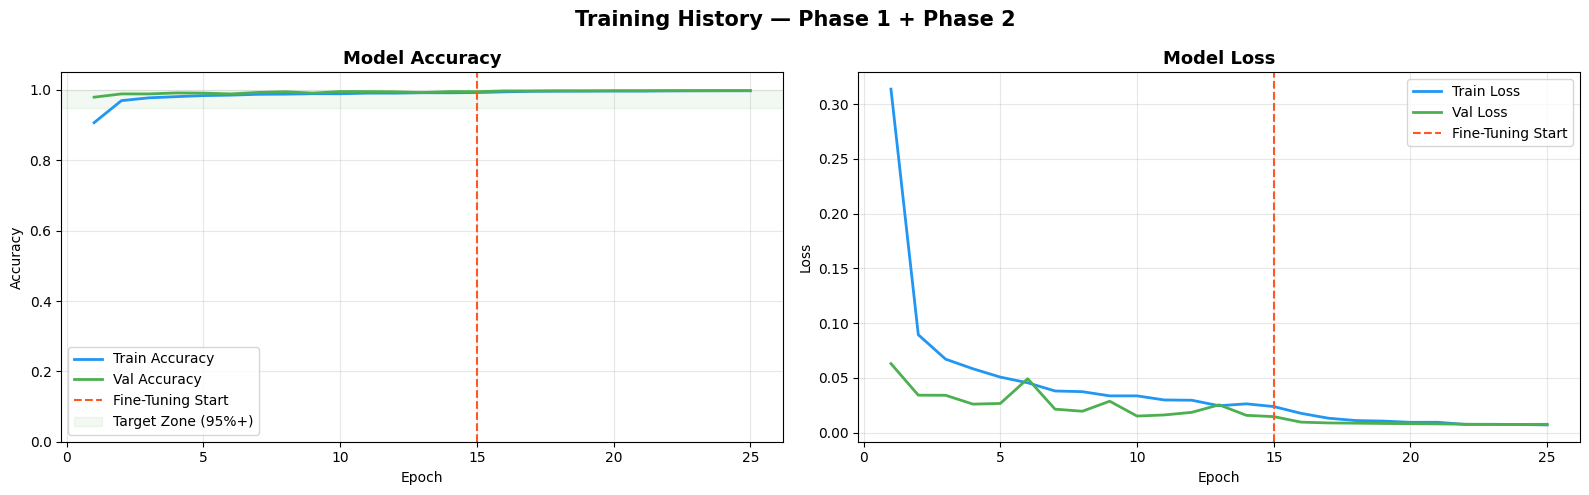


📊 ملخص النتائج:
   Phase 1 → best val_acc: 0.9954
   Phase 2 → best val_acc: 0.9979
   🏆 أحسن val_accuracy إجمالاً: 0.9979 (99.79%)


In [13]:
def plot_full_history(history1, history2):
    acc      = history1.history['accuracy']     + history2.history['accuracy']
    val_acc  = history1.history['val_accuracy'] + history2.history['val_accuracy']
    loss     = history1.history['loss']         + history2.history['loss']
    val_loss = history1.history['val_loss']     + history2.history['val_loss']
    split    = len(history1.history['accuracy'])
    epochs_x = range(1, len(acc) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    colors = {'train_acc': '#2196F3', 'val_acc': '#4CAF50',
              'train_loss': '#2196F3', 'val_loss': '#4CAF50', 'split': '#FF5722'}

    # Accuracy
    axes[0].plot(epochs_x, acc,     label='Train Accuracy', color=colors['train_acc'], lw=2)
    axes[0].plot(epochs_x, val_acc, label='Val Accuracy',   color=colors['val_acc'],   lw=2)
    axes[0].axvline(x=split, color=colors['split'], ls='--', lw=1.5, label='Fine-Tuning Start')
    axes[0].axhspan(0.95, 1.0, alpha=0.05, color='green', label='Target Zone (95%+)')
    axes[0].set_title('Model Accuracy', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy')
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0, 1.05])

    # Loss
    axes[1].plot(epochs_x, loss,     label='Train Loss', color=colors['train_loss'], lw=2)
    axes[1].plot(epochs_x, val_loss, label='Val Loss',   color=colors['val_loss'],   lw=2)
    axes[1].axvline(x=split, color=colors['split'], ls='--', lw=1.5, label='Fine-Tuning Start')
    axes[1].set_title('Model Loss', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    plt.suptitle('Training History — Phase 1 + Phase 2', fontsize=15, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/content/training_history.png', dpi=150, bbox_inches='tight')
    plt.show()

    print(f'\n📊 ملخص النتائج:')
    print(f'   Phase 1 → best val_acc: {max(history1.history["val_accuracy"]):.4f}')
    print(f'   Phase 2 → best val_acc: {max(history2.history["val_accuracy"]):.4f}')
    overall_best = max(max(history1.history['val_accuracy']), max(history2.history['val_accuracy']))
    print(f'   🏆 أحسن val_accuracy إجمالاً: {overall_best:.4f} ({overall_best*100:.2f}%)')

plot_full_history(history1, history2)

## 🎯 الخطوة 13 — تقييم نهائي على Validation Set

In [14]:
print('📊 تقييم نهائي ...')
val_loss, val_acc = model.evaluate(val_ds, verbose=1)
print(f'\n✅ Val Loss:     {val_loss:.4f}')
print(f'✅ Val Accuracy: {val_acc:.4f}  ({val_acc*100:.2f}%)')

if val_acc >= 0.95:
    print('🏆 ممتاز! الموديل وصل لـ 95%+')
elif val_acc >= 0.90:
    print('✅ كويس — الموديل فوق 90%')
else:
    print('⚠️  الأكيوراسي أقل من المتوقع — جرّب أكتر epochs في الـ Phase 2')

📊 تقييم نهائي ...
275/275 ━━━━━━━━━━━━━━━━━━━━ 12s 45ms/step - accuracy: 0.9979 - loss: 0.0077

✅ Val Loss:     0.0077
✅ Val Accuracy: 0.9979  (99.79%)
🏆 ممتاز! الموديل وصل لـ 95%+


## 🔍 الخطوة 14 — Confusion Matrix

⏳ جاري حساب التنبؤات ...


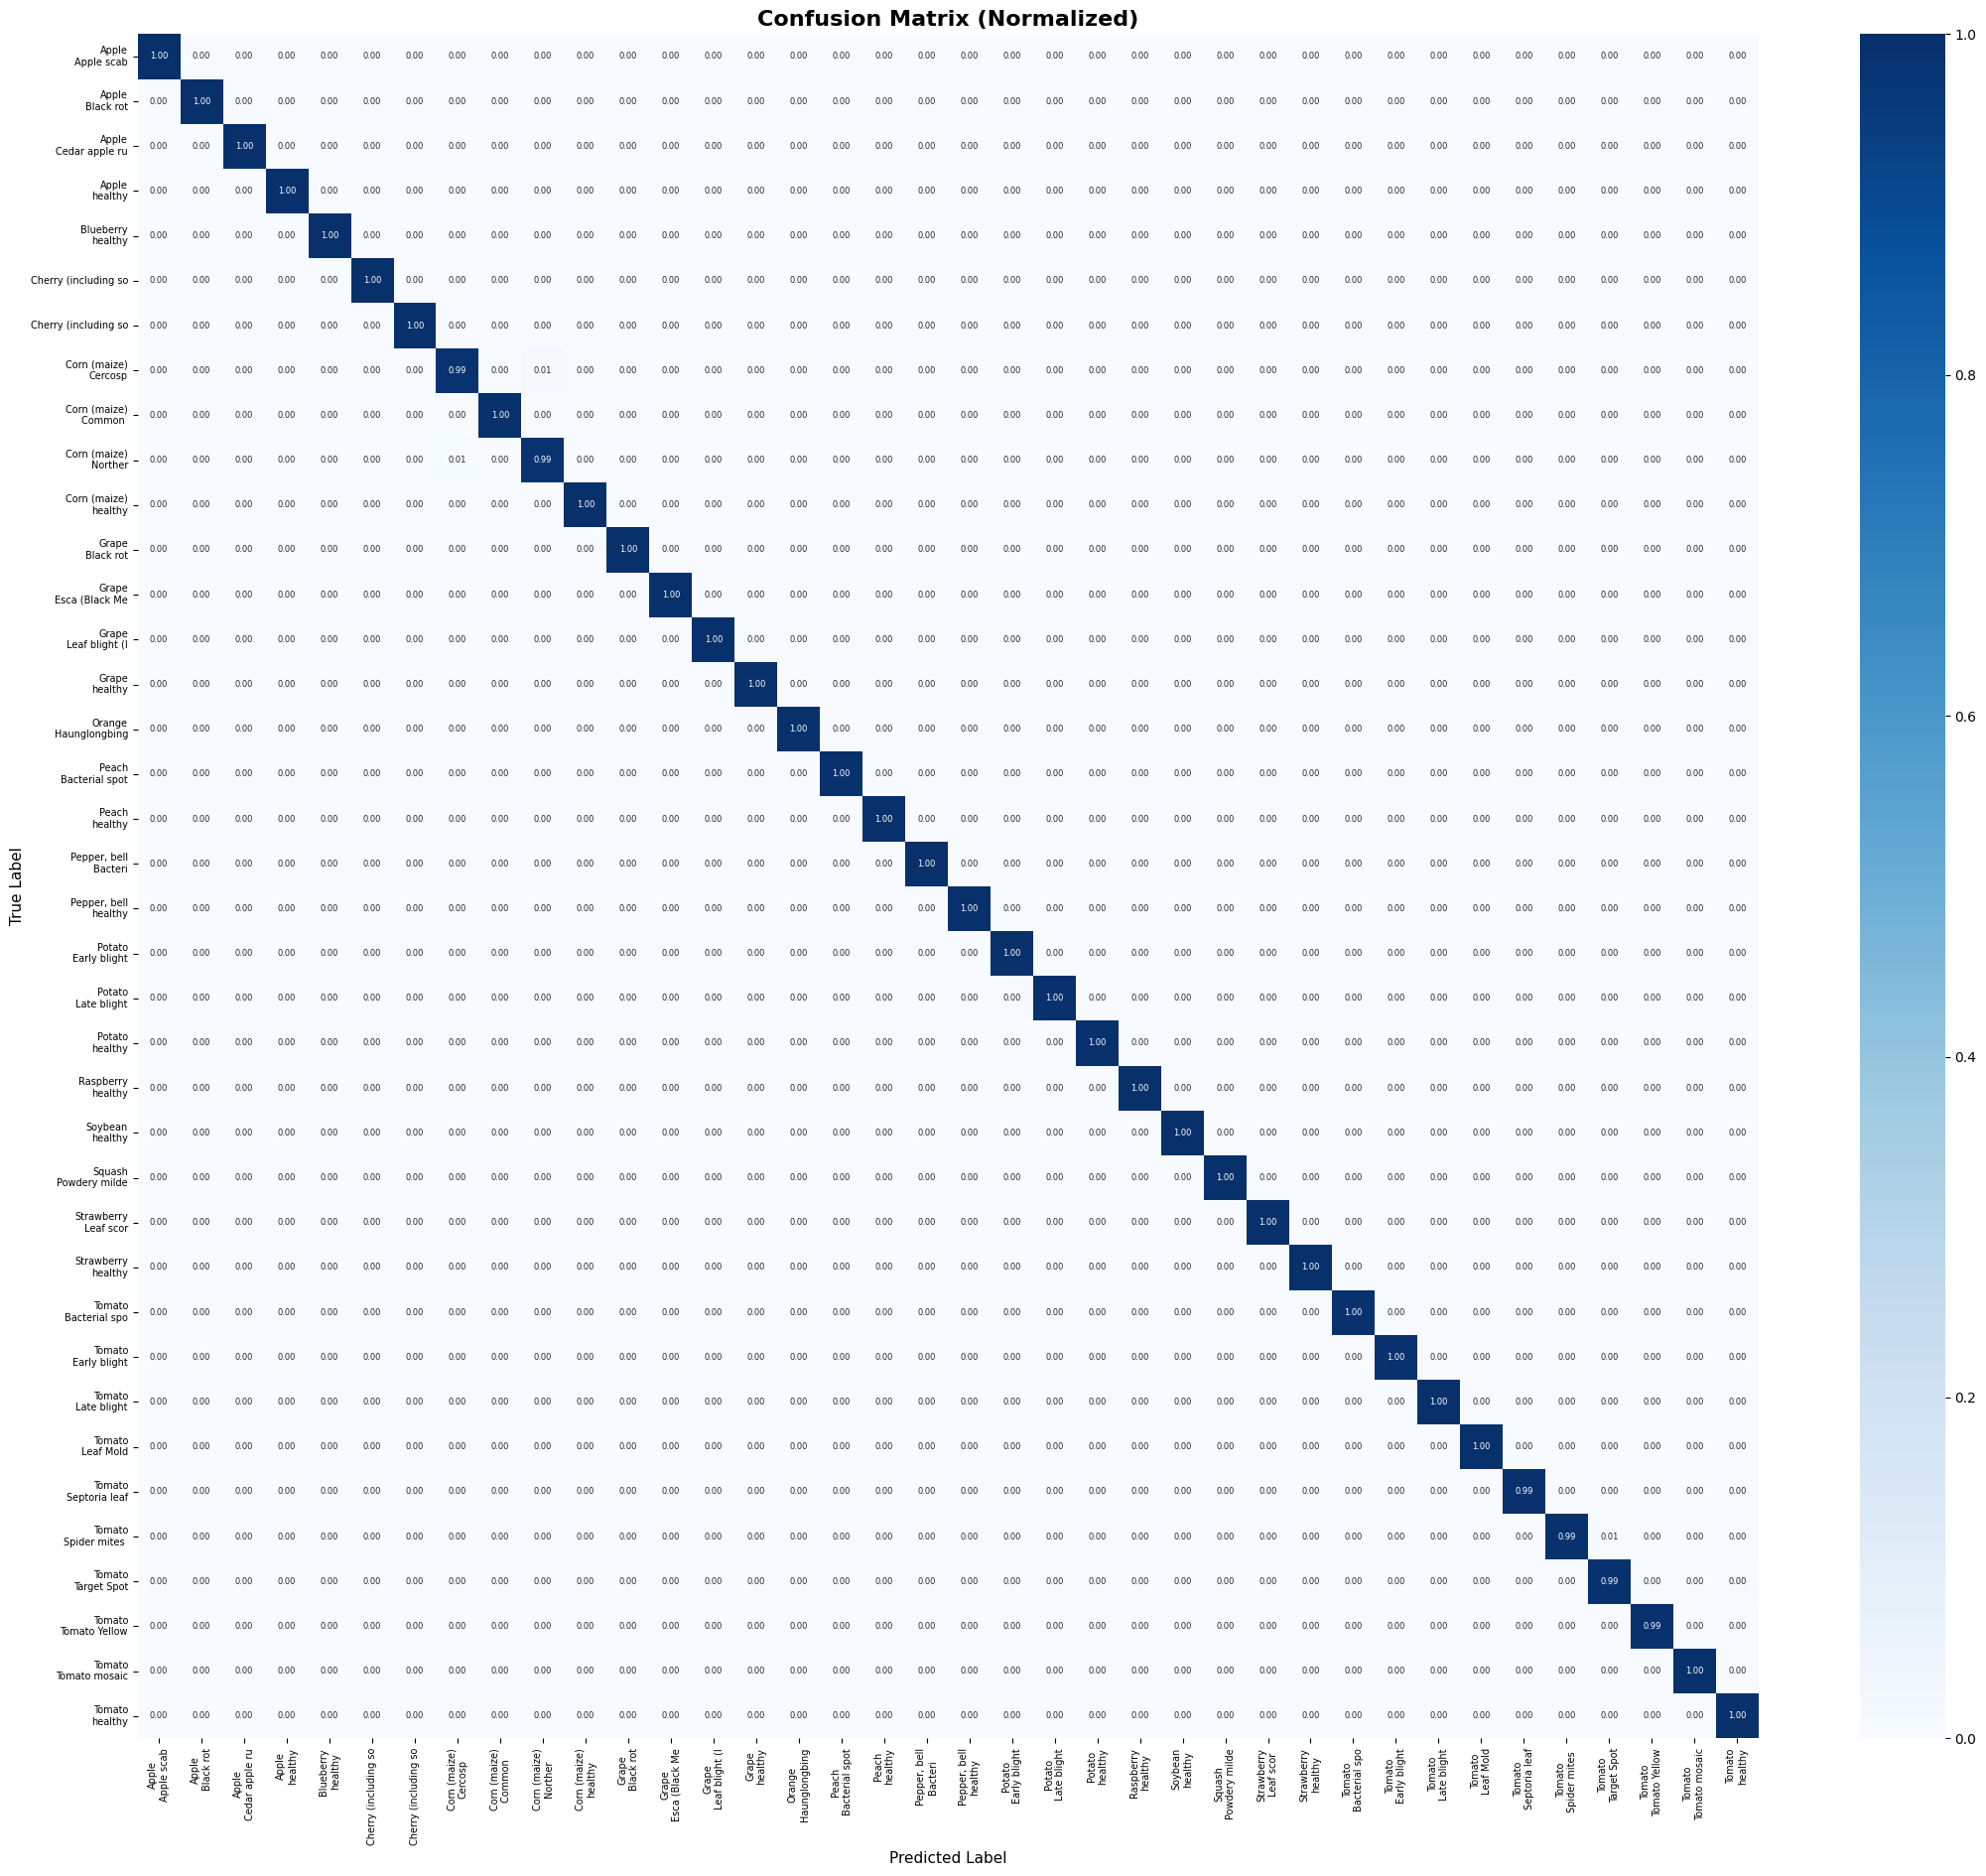


⚠️  أضعف 5 كلاسات:
   Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot → 98.5%
   Corn_(maize)___Northern_Leaf_Blight           → 98.7%
   Tomato___Spider_mites Two-spotted_spider_mite → 99.1%
   Tomato___Target_Spot                          → 99.1%
   Tomato___Septoria_leaf_spot                   → 99.3%


In [15]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

print('⏳ جاري حساب التنبؤات ...')
y_true, y_pred = [], []
for images, labels in val_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred)

# Normalize
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

short_names = [c.replace('___', '\n').replace('_', ' ')[:20] for c in CLASS_NAMES]

plt.figure(figsize=(22, 19))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=short_names, yticklabels=short_names,
            annot_kws={'size': 6}, vmin=0, vmax=1)
plt.title('Confusion Matrix (Normalized)', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0,  fontsize=7)
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# أضعف 5 كلاسات
per_class_acc = cm_norm.diagonal()
worst_5 = np.argsort(per_class_acc)[:5]
print('\n⚠️  أضعف 5 كلاسات:')
for i in worst_5:
    print(f'   {CLASS_NAMES[i]:45s} → {per_class_acc[i]*100:.1f}%')

## 🌿 الخطوة 15 — اختبار صور من الـ Val Set

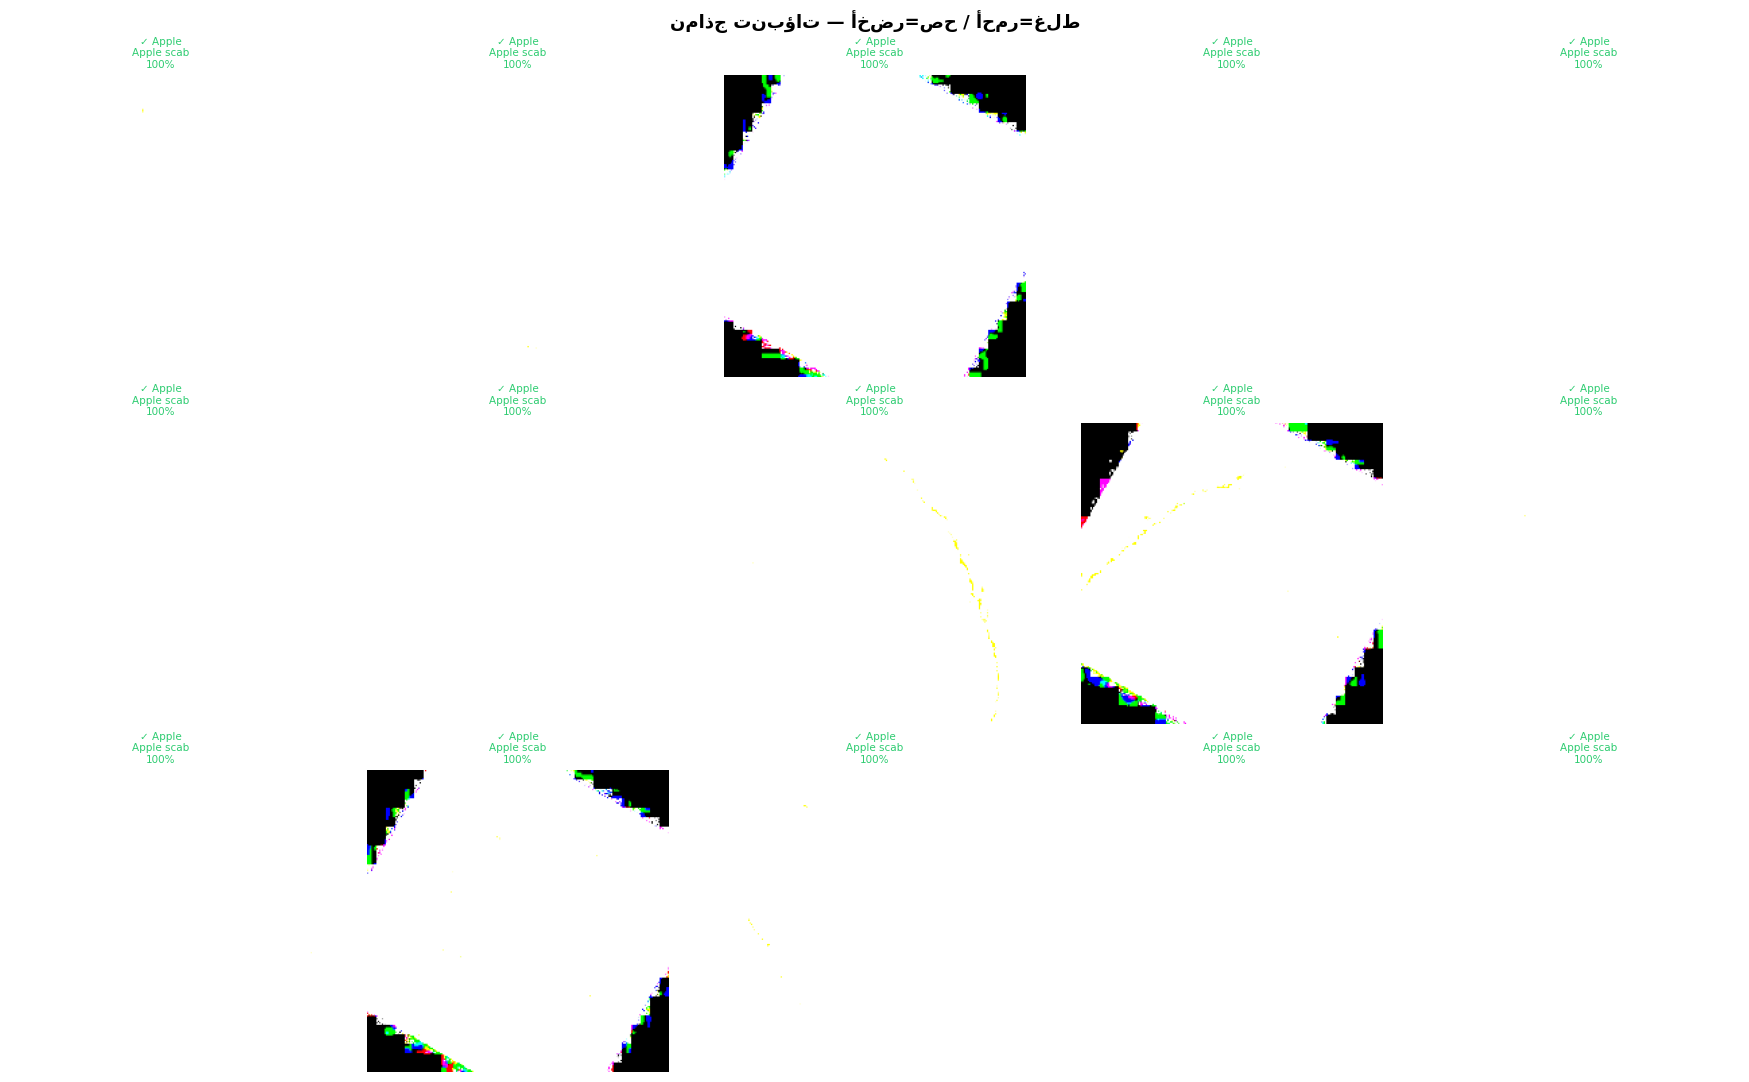

In [16]:
fig, axes = plt.subplots(3, 5, figsize=(18, 11))
axes = axes.flatten()

sample_images, sample_labels = next(iter(val_ds))
sample_preds = model.predict(sample_images[:15], verbose=0)

for i in range(15):
    img   = sample_images[i].numpy()
    true  = CLASS_NAMES[sample_labels[i].numpy()]
    pred  = CLASS_NAMES[np.argmax(sample_preds[i])]
    conf  = np.max(sample_preds[i]) * 100
    correct = true == pred

    axes[i].imshow(img)

    # إطار أخضر = صح، أحمر = غلط
    color = '#2ecc71' if correct else '#e74c3c'
    for spine in axes[i].spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(3)

    t = true.replace('___', '\n').replace('_', ' ')
    p = pred.replace('___', '\n').replace('_', ' ')
    title = f'✓ {p[:20]}\n{conf:.0f}%' if correct else f'✗ pred: {p[:15]}\ntrue: {t[:15]}'
    axes[i].set_title(title, fontsize=7.5,
                       color='#2ecc71' if correct else '#e74c3c')
    axes[i].axis('off')

plt.suptitle('نماذج تنبؤات — أخضر=صح / أحمر=غلط', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 الخطوة 16 — حفظ الموديل وملف الكلاسات

In [17]:
# ── حفظ الموديل ─────────────────────────────────────────────────
MODEL_SAVE_PATH = '/content/plant_disease_model_final.keras'
model.save(MODEL_SAVE_PATH)
size_mb = os.path.getsize(MODEL_SAVE_PATH) / (1024*1024)
print(f'✅ تم حفظ الموديل: {MODEL_SAVE_PATH}  ({size_mb:.1f} MB)')

# ── حفظ أسماء الكلاسات ──────────────────────────────────────────
with open('/content/class_names.json', 'w', encoding='utf-8') as f:
    json.dump(CLASS_NAMES, f, ensure_ascii=False, indent=2)
print(f'✅ تم حفظ الكلاسات: /content/class_names.json  ({NUM_CLASSES} كلاس)')

# ── نسخ كل حاجة على Drive ───────────────────────────────────────
RESULTS_PATH = '/content/drive/MyDrive/plant_disease_results/'
!mkdir -p "{RESULTS_PATH}"
!cp /content/plant_disease_model_final.keras "{RESULTS_PATH}"
!cp /content/class_names.json               "{RESULTS_PATH}"
!cp /content/training_history.png           "{RESULTS_PATH}"
!cp /content/confusion_matrix.png           "{RESULTS_PATH}"
!cp /content/sample_predictions.png         "{RESULTS_PATH}"
print(f'\n✅ كل الملفات اتحفظت على Drive: {RESULTS_PATH}')
!ls -lh "{RESULTS_PATH}"

✅ تم حفظ الموديل: /content/plant_disease_model_final.keras  (143.3 MB)
✅ تم حفظ الكلاسات: /content/class_names.json  (38 كلاس)

✅ كل الملفات اتحفظت على Drive: /content/drive/MyDrive/plant_disease_results/
total 144M
-rw-r--r-- 1 root root 1.2K Apr 28 22:22 class_names.json
-rw-r--r-- 1 root root 319K Apr 28 22:22 confusion_matrix.png
-rw-r--r-- 1 root root 144M Apr 28 22:22 plant_disease_model_final.keras
-rw-r--r-- 1 root root 114K Apr 28 22:22 sample_predictions.png
-rw-r--r-- 1 root root  97K Apr 28 22:22 training_history.png


## 🌿 الخطوة 17 — تنبؤ على صورة واحدة (اختبار يدوي)

In [ ]:
import io
from PIL import Image as PILImage

def predict_image(img_path, model=model, class_names=CLASS_NAMES):
    """
    تنبؤ لصورة نبتة واحدة مع عرض النتيجة
    """
    img = tf.keras.utils.load_img(img_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = np.expand_dims(arr / 255.0, axis=0)

    preds   = model.predict(arr, verbose=0)[0]
    top_idx = np.argmax(preds)
    conf    = preds[top_idx] * 100
    top5    = np.argsort(preds)[-5:][::-1]

    cls     = class_names[top_idx]
    parts   = cls.split('___')
    plant   = parts[0].replace('_', ' ')
    disease = parts[1].replace('_', ' ') if len(parts) > 1 else ''

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

    # الصورة
    ax1.imshow(img)
    ax1.axis('off')
    status = '🟢 سليم' if 'healthy' in cls.lower() else '🔴 مريض'
    ax1.set_title(f'{status}\n{plant} — {disease}\nثقة: {conf:.1f}%',
                  fontsize=12, fontweight='bold', pad=10)

    # Top 5 bars
    top5_names  = [class_names[i].replace('___', '\n').replace('_',' ')[:25] for i in top5]
    top5_confs  = [preds[i]*100 for i in top5]
    colors_bar  = ['#2ecc71' if i==0 else '#95a5a6' for i in range(5)]
    bars = ax2.barh(range(4, -1, -1), top5_confs, color=colors_bar)
    ax2.set_yticks(range(4, -1, -1))
    ax2.set_yticklabels(top5_names, fontsize=8)
    ax2.set_xlabel('Confidence %')
    ax2.set_title('أفضل 5 نتائج', fontsize=12, fontweight='bold')
    ax2.set_xlim([0, 105])
    for bar, val in zip(bars, top5_confs):
        ax2.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
    ax2.grid(axis='x', alpha=0.3)

    plt.suptitle('🌿 نتيجة التنبؤ', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {'class': cls, 'confidence': conf}


# ── اختبار تلقائي بأول صورة من الـ Val set ──────────────────────
first_class_dir = os.path.join(VAL_DIR, CLASS_NAMES[0])
first_image     = os.path.join(first_class_dir, os.listdir(first_class_dir)[0])
print(f'🧪 اختبار على: {first_image}')
result = predict_image(first_image)
print(f'\n✅ النتيجة: {result["class"]} — ثقة: {result["confidence"]:.1f}%')

---
## 📋 ملخص كل حاجة اتعملت

| الخطوة | التفاصيل |
|---|---|
| **Base Model** | EfficientNetV2S pretrained على ImageNet |
| **Image Size** | 224×224 |
| **Batch Size** | 128 (محسّن لـ L4 24GB) |
| **Mixed Precision** | float16 (أسرع 1.5-2x) |
| **Phase 1** | 20 epochs — Base frozen — LR=1e-3 |
| **Phase 2** | 15 epochs — آخر 30 طبقة مفتوحة — LR=1e-5 |
| **Callbacks** | EarlyStopping + ReduceLROnPlateau + ModelCheckpoint |
| **Data Pipeline** | cache + shuffle(5000) + prefetch(AUTOTUNE) |
| **Augmentation** | Flip + Rotation + Zoom + Brightness + Contrast |

### الملفات المحفوظة على Drive
```
MyDrive/plant_disease_results/
├── plant_disease_model_final.keras  ← الموديل النهائي
├── class_names.json                 ← أسماء الكلاسات (للـ API)
├── training_history.png             ← رسم التدريب
├── confusion_matrix.png             ← Confusion Matrix
└── sample_predictions.png           ← نماذج تنبؤات
```
